# 라이브러리 불러오기

In [1]:
import os
import pandas as pd
import numpy as np
import datetime
import holidays
import matplotlib.pyplot as plt
import seaborn as sns

from korean_font import set_korean_font

import warnings
warnings.filterwarnings("ignore")

set_korean_font()

한글 폰트 설정: NanumGothic (/usr/share/fonts/truetype/nanum/NanumGothic.ttf)


In [2]:
# 경로 설정
HOME = os.getcwd()

trainpath = os.path.join(HOME, 'data', 'train.csv')
testpath = os.path.join(HOME, 'data', 'test.csv')
subpath = os.path.join(HOME, 'data', 'sample_submission.csv')
interpath = os.path.join(HOME, 'data', 'international_trade.csv')

In [3]:
# 파일 읽기
train_df = pd.read_csv(trainpath)
test_df = pd.read_csv(testpath)
sub_df = pd.read_csv(subpath)
inter_df = pd.read_csv(interpath)

# 데이터 분석

### 1. 품목별 데이터 분포 확인

In [4]:
train_df.rename(columns={'supply(kg)':'supply', 'price(원/kg)':'price'}, inplace = True)

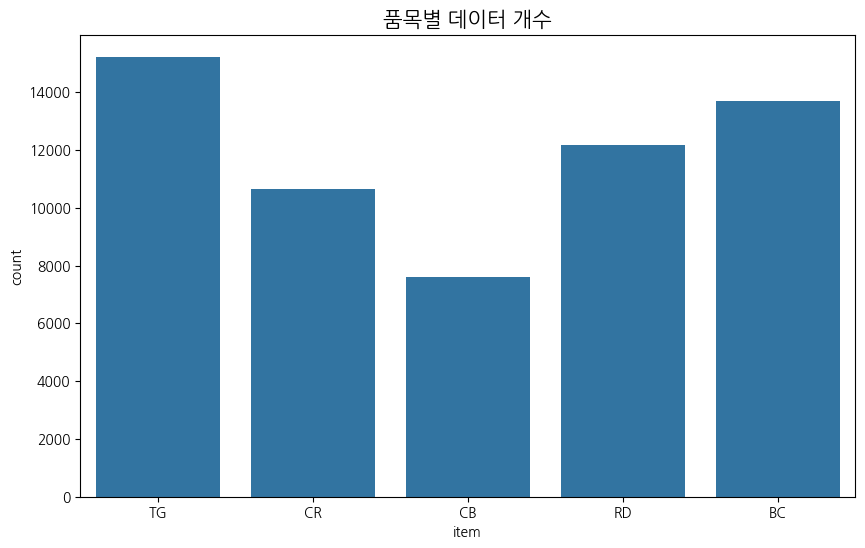

In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(x='item', data=train_df)

plt.title('품목별 데이터 개수', fontsize=15)
plt.show()

### 2. 일일 가격 변동 그래프

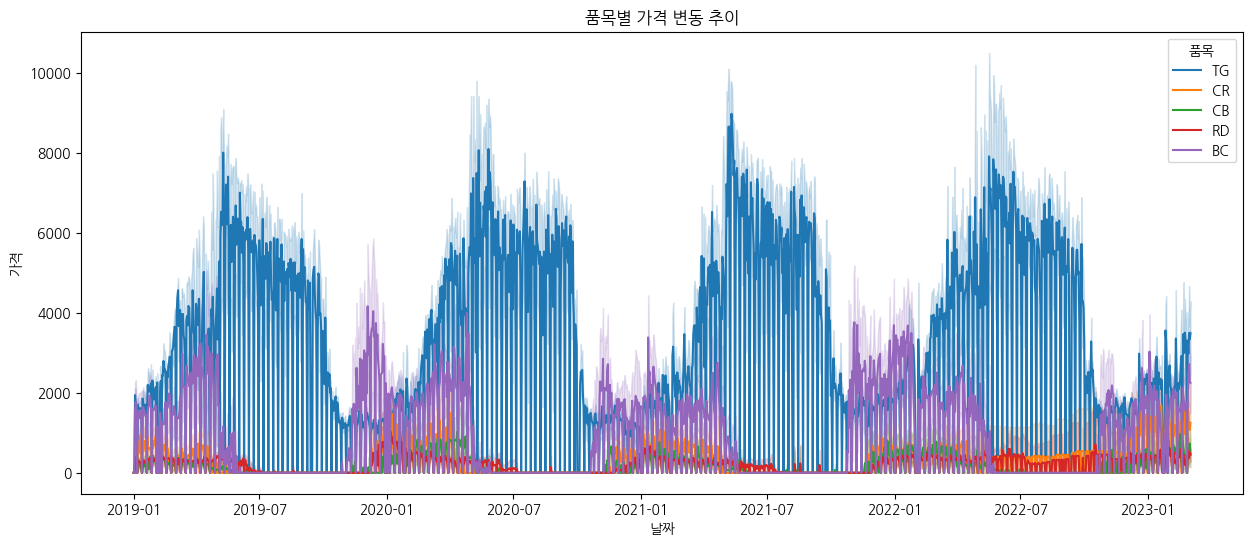

In [6]:
# 데이터 타입 변환 및 준비
train_df['timestamp'] = pd.to_datetime(train_df['timestamp'])

# 품목별 평균 가격 시각화
plt.figure(figsize=(15, 6))
sns.lineplot(data=train_df, x='timestamp', y='price', hue='item')
plt.title('품목별 가격 변동 추이')
plt.ylabel('가격')
plt.xlabel('날짜')
plt.legend(title='품목')
plt.show()

* 일정한 주기로 비슷한 패턴이 형성되는게 보이지만 TG와 CR, RD와 CB, BC가 세 종류의 다른 모습을 보여줌

### 2. 월별 가격 분포

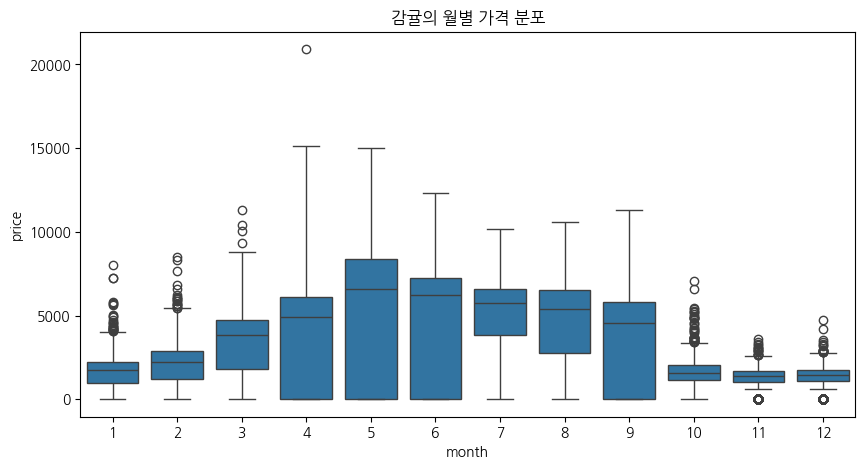

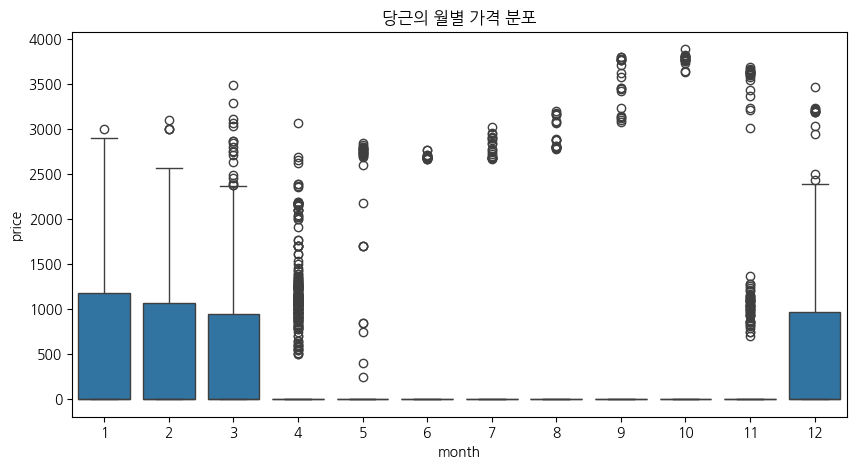

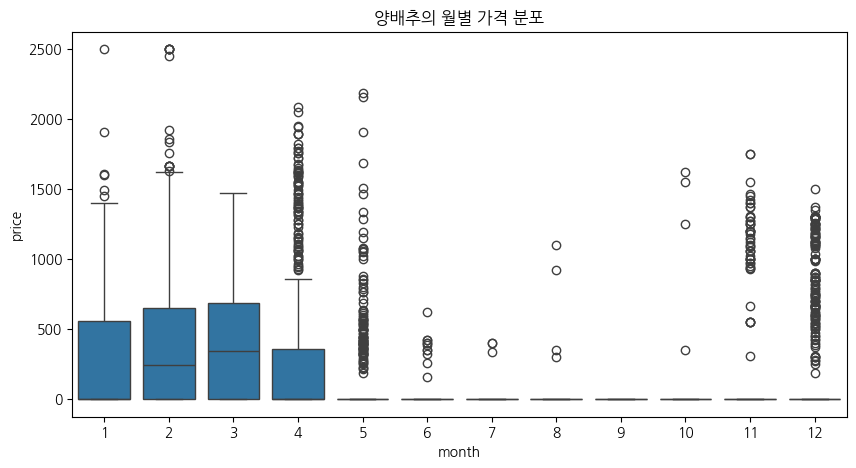

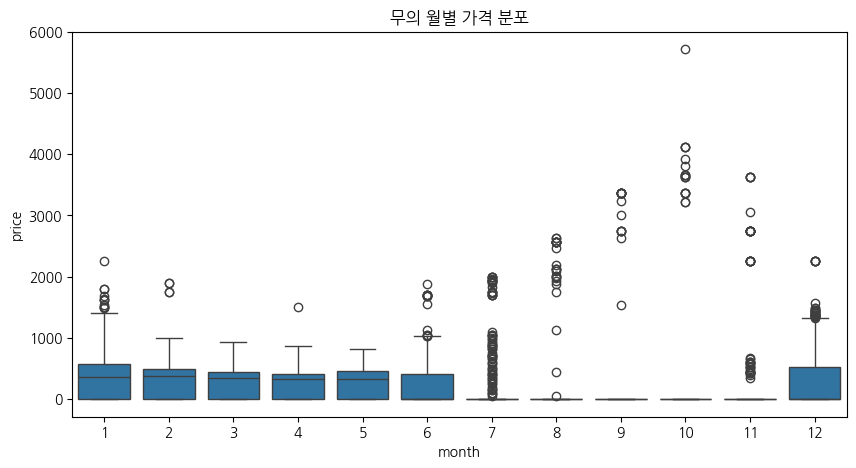

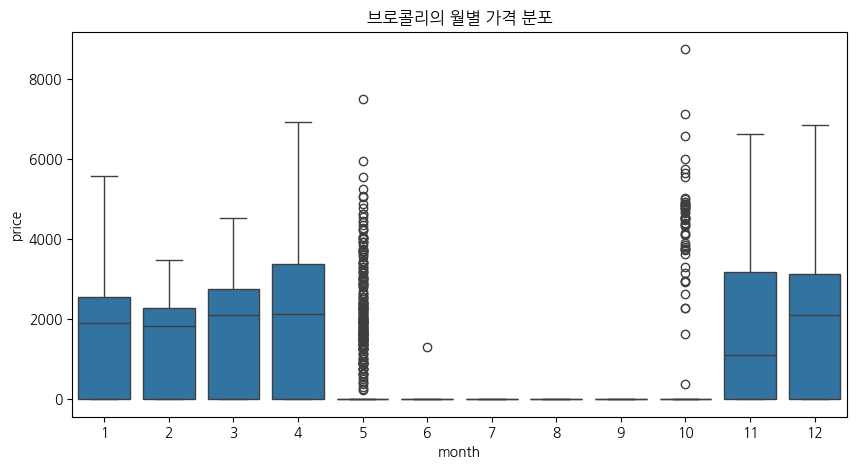

In [7]:
train_df['month'] = train_df['timestamp'].dt.month
plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df[train_df['item'] == 'TG'], x='month', y='price')
plt.title('감귤의 월별 가격 분포')
plt.show()

train_df['month'] = train_df['timestamp'].dt.month
plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df[train_df['item'] == 'CR'], x='month', y='price')
plt.title('당근의 월별 가격 분포')
plt.show()

train_df['month'] = train_df['timestamp'].dt.month
plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df[train_df['item'] == 'CB'], x='month', y='price')
plt.title('양배추의 월별 가격 분포')
plt.show()

train_df['month'] = train_df['timestamp'].dt.month
plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df[train_df['item'] == 'RD'], x='month', y='price')
plt.title('무의 월별 가격 분포')
plt.show()

train_df['month'] = train_df['timestamp'].dt.month
plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df[train_df['item'] == 'BC'], x='month', y='price')
plt.title('브로콜리의 월별 가격 분포')
plt.show()

* TG를 제외하곤 비슷한 가격 분포를 보여줌
* 겨울, 봄에 많이 판매가 됐음을 알 수 있음
* 유독 튀는 이상치가 존재함

### 3. 연도별 가격 분포

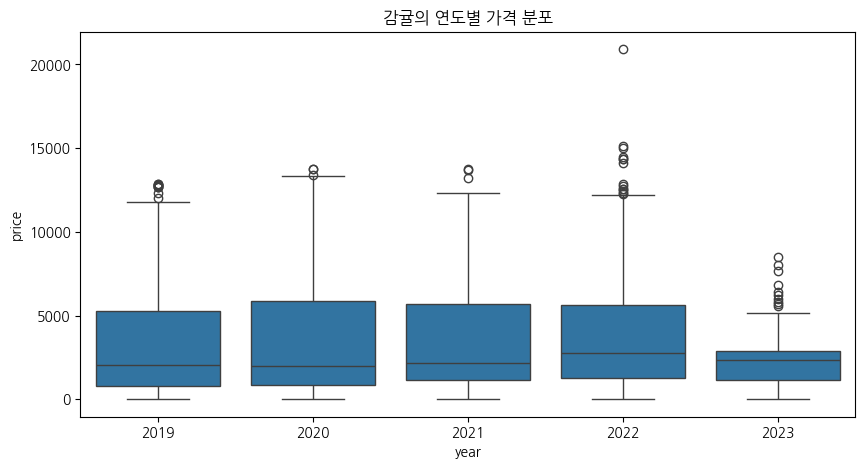

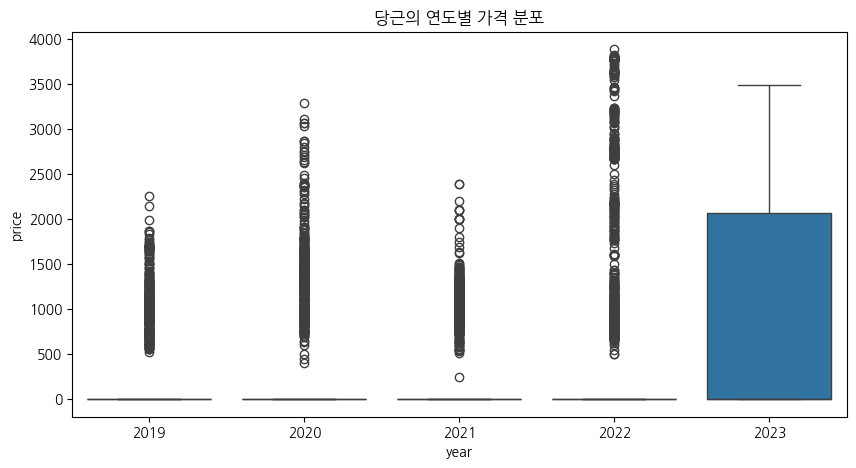

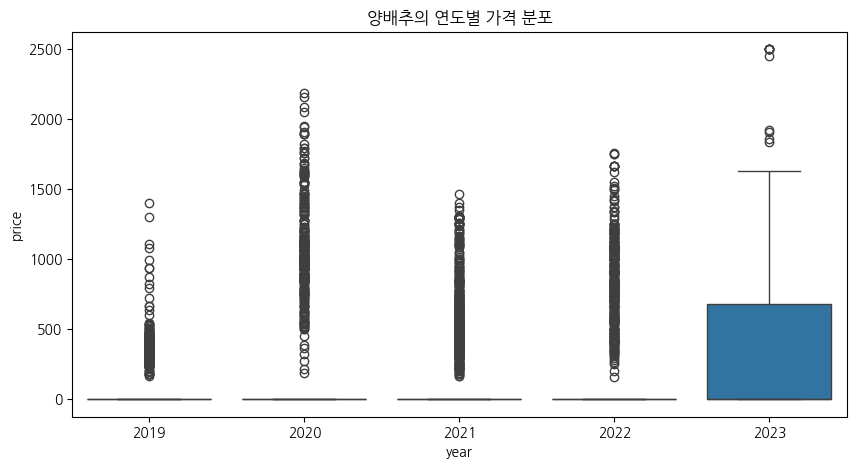

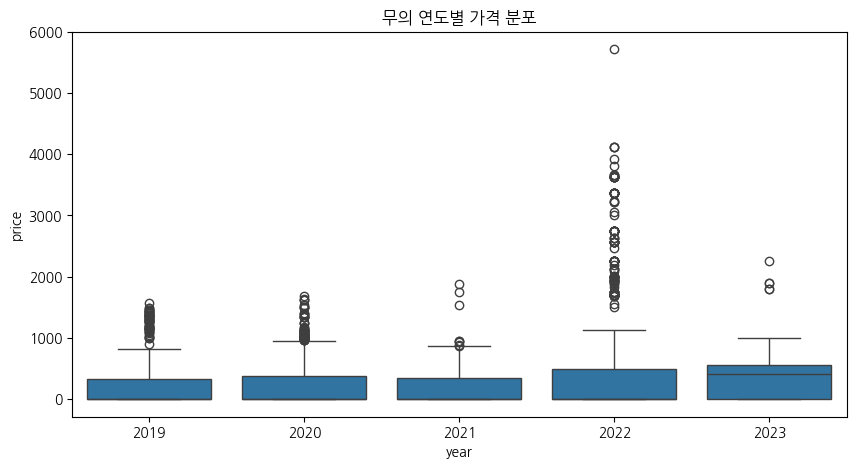

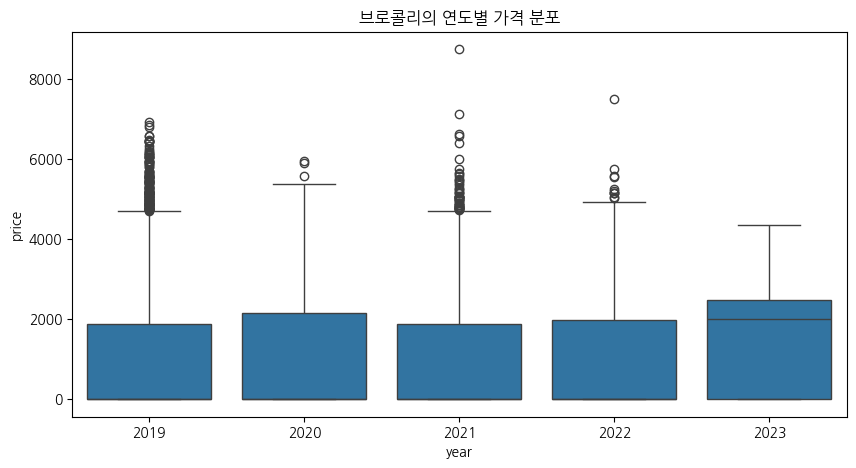

In [8]:
train_df['year'] = train_df['timestamp'].dt.year
plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df[train_df['item'] == 'TG'], x='year', y='price')
plt.title('감귤의 연도별 가격 분포')
plt.show()

train_df['year'] = train_df['timestamp'].dt.year
plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df[train_df['item'] == 'CR'], x='year', y='price')
plt.title('당근의 연도별 가격 분포')
plt.show()

train_df['year'] = train_df['timestamp'].dt.year
plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df[train_df['item'] == 'CB'], x='year', y='price')
plt.title('양배추의 연도별 가격 분포')
plt.show()

train_df['year'] = train_df['timestamp'].dt.year
plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df[train_df['item'] == 'RD'], x='year', y='price')
plt.title('무의 연도별 가격 분포')
plt.show()

train_df['year'] = train_df['timestamp'].dt.year
plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df[train_df['item'] == 'BC'], x='year', y='price')
plt.title('브로콜리의 연도별 가격 분포')
plt.show()

### 4. 계절 별 가격 분포

In [9]:
# 위의 시각화 이미지를 토대로 4계절 컬럼 생성
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'
        
train_df['season'] = train_df['month'].apply(get_season)

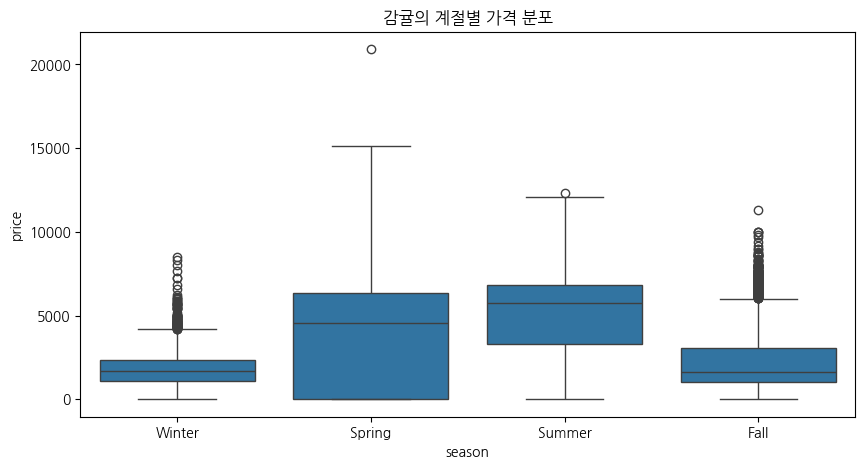

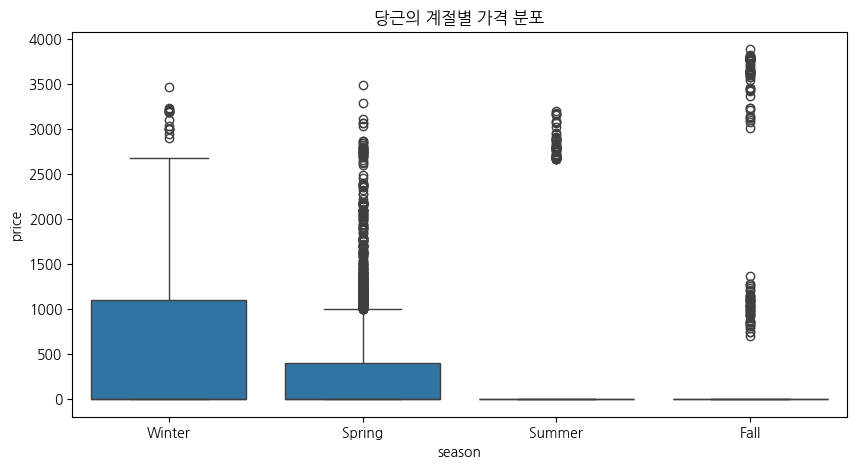

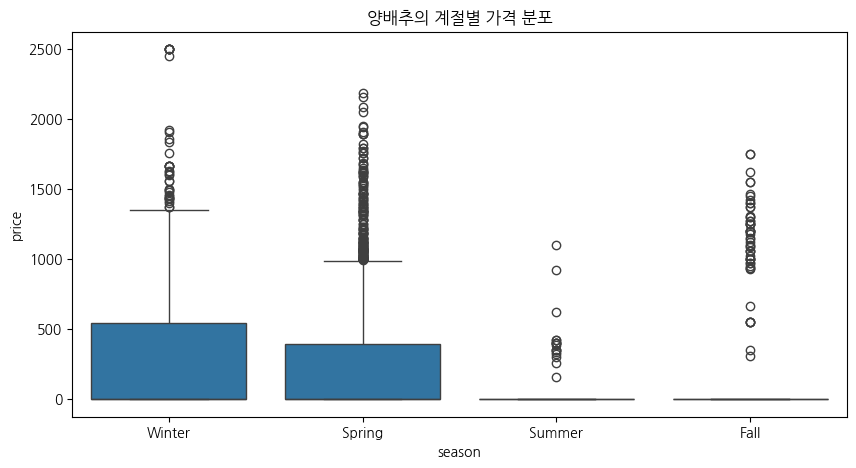

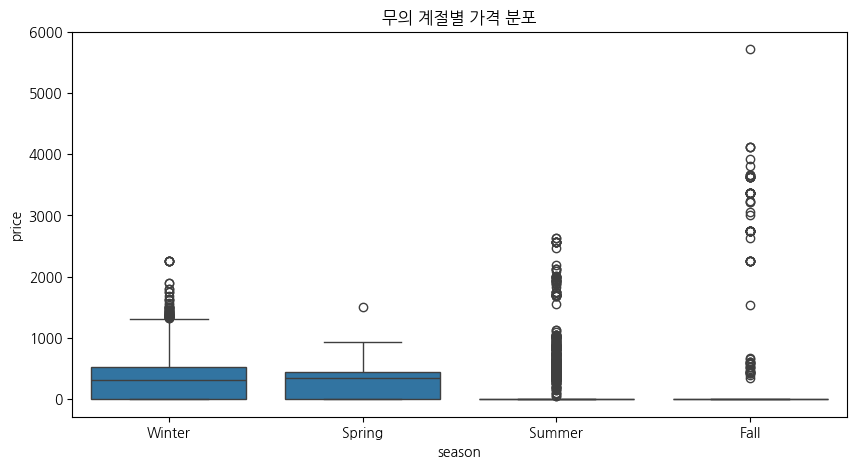

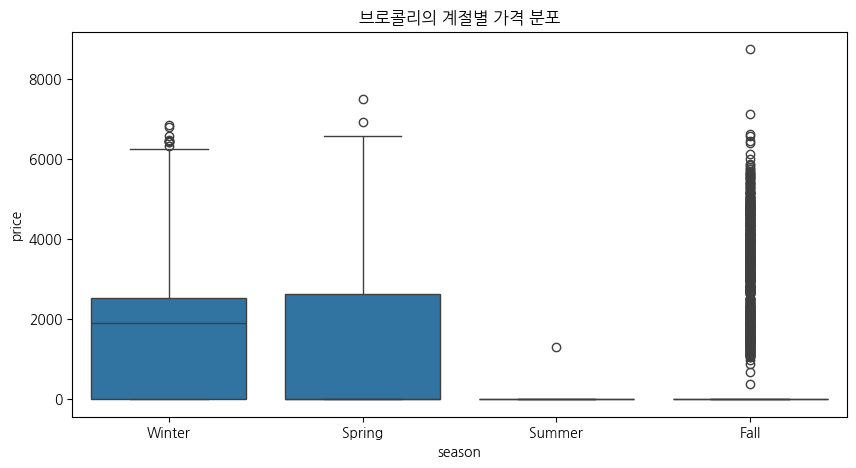

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df[train_df['item'] == 'TG'], x='season', y='price')
plt.title('감귤의 계절별 가격 분포')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df[train_df['item'] == 'CR'], x='season', y='price')
plt.title('당근의 계절별 가격 분포')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df[train_df['item'] == 'CB'], x='season', y='price')
plt.title('양배추의 계절별 가격 분포')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df[train_df['item'] == 'RD'], x='season', y='price')
plt.title('무의 계절별 가격 분포')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df[train_df['item'] == 'BC'], x='season', y='price')
plt.title('브로콜리의 계절별 가격 분포')
plt.show()

### 5. 이상치 확인

 TG   | Q1:   1802.5 | Q3:   6037.0 | 상한선:  12388.8 | 이상치:   30개
 CR   | Q1:    923.2 | Q3:   1699.2 | 상한선:   2863.2 | 이상치:  104개
 CB   | Q1:    396.8 | Q3:    975.2 | 상한선:   1843.0 | 이상치:   20개
 RD   | Q1:    385.0 | Q3:    578.2 | 상한선:    868.1 | 이상치:  334개
 BC   | Q1:   2050.0 | Q3:   3321.0 | 상한선:   5227.5 | 이상치:  100개


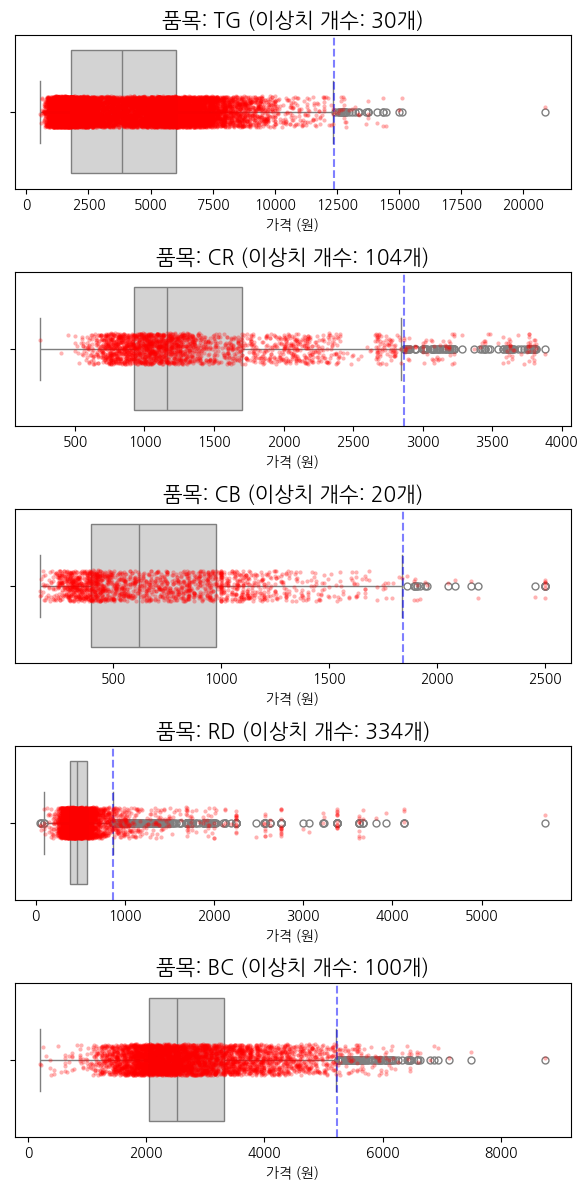

In [11]:
# 품목 리스트 정의
items = train_df['item'].unique()

# 5개의 품목을 그리기 위해 5행 1열의 subplot 생성
fig, axes = plt.subplots(5, 1, figsize=(6, 12))

for i, item_name in enumerate(items):
    # 해당 품목 추출 (가격 0원 제외 - 경매 없는 날은 이상치 분석에서 제외하는 것이 정확함)
    target_df = train_df[(train_df['item'] == item_name) & (train_df['price'] > 0)]
    
    # --- IQR 계산 ---
    Q1 = target_df['price'].quantile(0.25)
    Q3 = target_df['price'].quantile(0.75)
    IQR = Q3 - Q1
    
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
    
    # 이상치 개수 파악
    outliers_count = len(target_df[(target_df['price'] > upper_bound) | (target_df['price'] < lower_bound)])
    
    # --- 시각화 (Boxplot + Strip클롯 결합) ---
    # Boxplot으로 사분위수를 보여주고, 그 위에 실제 데이터 점들을 뿌려 이상치 분포를 봅니다.
    sns.boxplot(data=target_df, x='price', ax=axes[i], color='lightgray', fliersize=5)
    sns.stripplot(data=target_df, x='price', ax=axes[i], color='red', alpha=0.3, size=3)
    
    # 제목 및 텍스트 추가
    axes[i].set_title(f"품목: {item_name} (이상치 개수: {outliers_count}개)", fontsize=15)
    axes[i].set_xlabel("가격 (원)")
    
    # 배경에 상한선 표시 (가독성 증대)
    axes[i].axvline(upper_bound, color='blue', linestyle='--', alpha=0.5, label='Upper Bound')
    
    print(f"{item_name:^5} | Q1: {Q1:>8.1f} | Q3: {Q3:>8.1f} | 상한선: {upper_bound:>8.1f} | 이상치: {outliers_count:>4}개")

plt.tight_layout()
plt.show()

* 이상치를 걸러내기 위해서 대략적인 위치를 확인

### 6. 유통사별 가격 분포


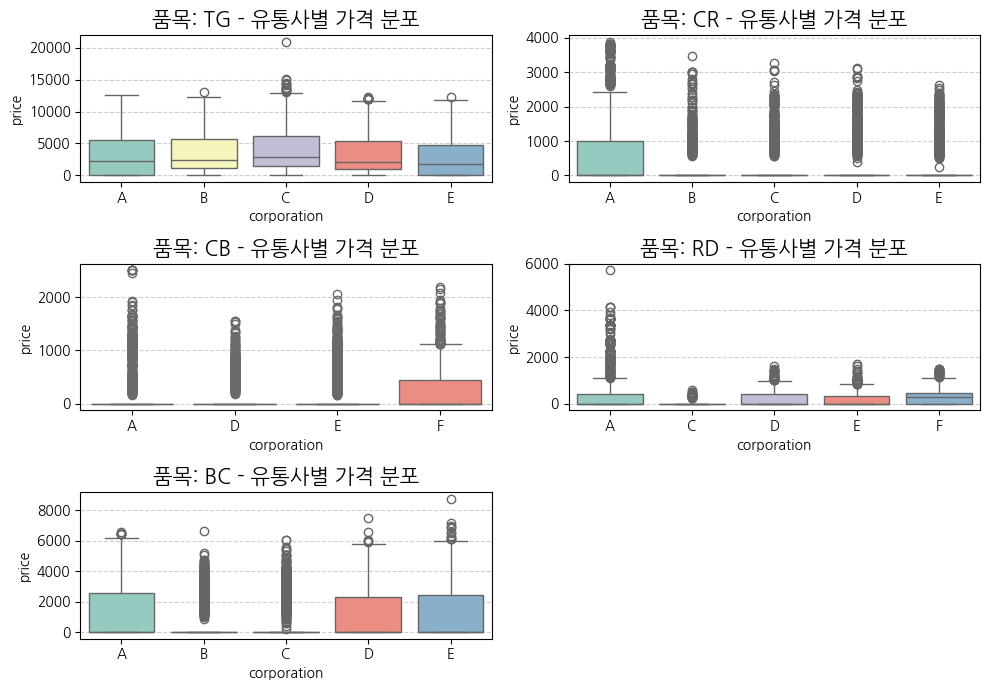

In [12]:
# 5개 품목 리스트
items = train_df['item'].unique()

# 유통사별 시각화
plt.figure(figsize=(10, 7))
for i, item in enumerate(items, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(data=train_df[train_df['item'] == item].sort_values('corporation'), 
                x='corporation', y='price', palette='Set3')
    plt.title(f'품목: {item} - 유통사별 가격 분포', fontsize=15)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

* TG를 제외한 4가지 품목은 0원 데이터가 많기 때문에 거의 대부분이 이상치로 보이는 중
* 임의의 박스권을 만들어서 생각하면 유통사 별 가격 분포는 비슷한 양상을 가짐

### 7. 지역별 가격 분포


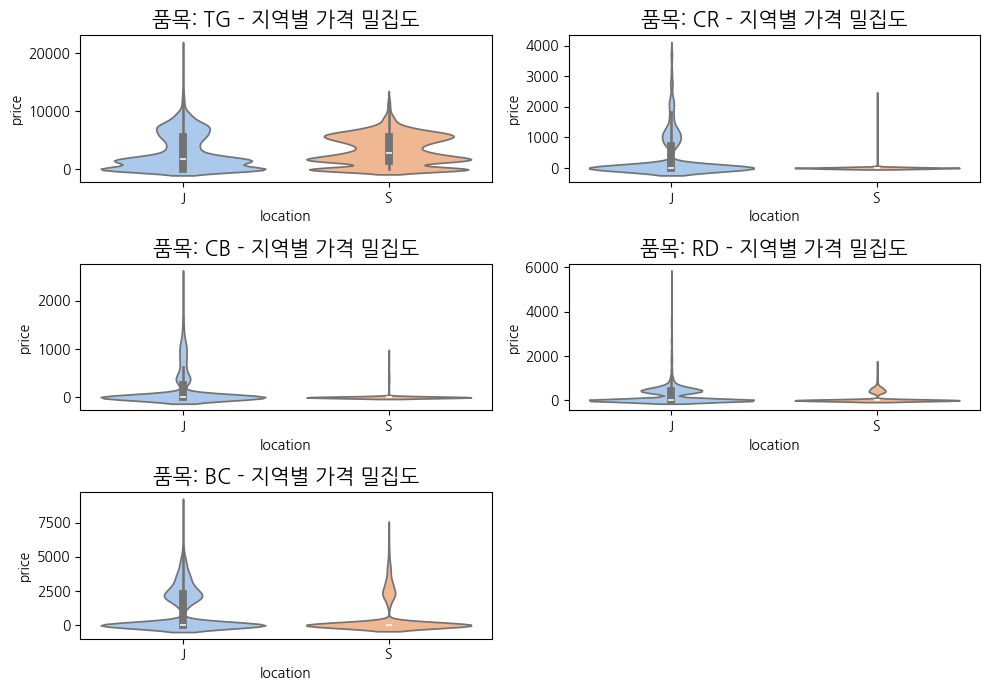

In [13]:
# 지역별 시각화
plt.figure(figsize=(10, 7))
for i, item in enumerate(items, 1):
    plt.subplot(3, 2, i)
    sns.violinplot(data=train_df[train_df['item'] == item], 
                   x='location', y='price', palette='pastel')
    plt.title(f'품목: {item} - 지역별 가격 밀집도', fontsize=15)

plt.tight_layout()
plt.show()

* 갯수에 차이가 있지만 가격에는 크게 차이가 없는 것으로 보임 (J가 S보다 비싸게 나오는 부분이 있더라도 그 갯수가 크지 않아보임)

### 8. 단순 이동평균 확인

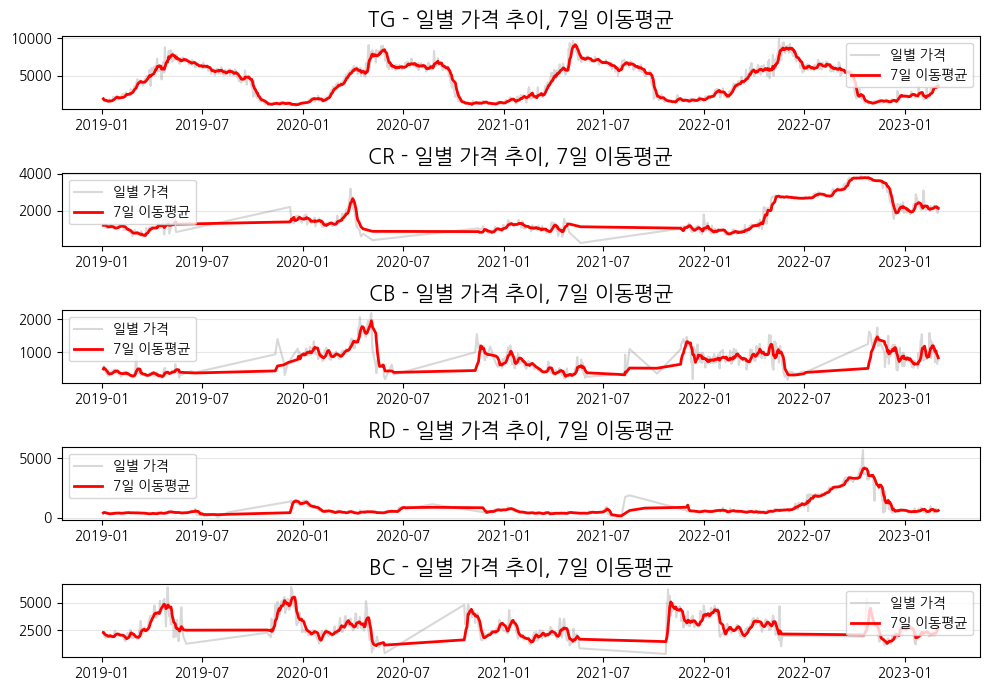

In [14]:
# 가격이 0원인 데이터를 데이터 생성
df_plot = train_df[train_df['price'] > 0].copy()
items = df_plot['item'].unique()

plt.figure(figsize=(10, 7))

for i, item in enumerate(items, 1):
    plt.subplot(5, 1, i)
    target = df_plot[df_plot['item'] == item].groupby('timestamp')['price'].mean().reset_index()
    
    # 7일 이동평균 계산
    target['rolling_7'] = target['price'].rolling(window=7, min_periods=1).mean()
    
    # 시각화
    plt.plot(target['timestamp'], target['price'], alpha=0.3, label='일별 가격', color='gray')
    plt.plot(target['timestamp'], target['rolling_7'], label='7일 이동평균', color='red', linewidth=2)
    
    plt.title(f'{item} - 일별 가격 추이, 7일 이동평균', fontsize=15)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

* 일일 가격 변동에서 봤듯이 CR과 RD에서는 22년 7월 이후 가격이 상승하는 모습을 볼 수 있음
* CB 와 BC는 당시 기후 상황에 따라 가격이 변동되는 것으로 확인됨

In [15]:
# 단순이동평균 보다 지수이동평균이 0원인 데이터가 많아도 금방 회복하는 모습을 보여줌
windows = [7, 30, 60, 120]
for w in windows:
    col_name = f'price_{w}d_avg'
    # 품목(item)별로 그룹화하여 계산
    train_df[col_name] = train_df.groupby('item')['price'].transform(
        lambda x: x.shift(1).ewm(span=w).mean()
    )

train_df

,ID,timestamp,item,corporation,location,supply,price,month,year,season,price_7d_avg,price_30d_avg,price_60d_avg,price_120d_avg
0,TG_A_J_20190101,2019-01-01,TG,A,J,0.0,0.0,1,2019,Winter,NaN,NaN,NaN,NaN
1,TG_A_J_20190102,2019-01-02,TG,A,J,0.0,0.0,1,2019,Winter,0.000000,0.000000,0.000000,0.000000
2,TG_A_J_20190103,2019-01-03,TG,A,J,60601.0,1728.0,1,2019,Winter,0.000000,0.000000,0.000000,0.000000
3,TG_A_J_20190104,2019-01-04,TG,A,J,25000.0,1408.0,1,2019,Winter,747.243243,614.812292,595.304879,585.626444
4,TG_A_J_20190105,2019-01-05,TG,A,J,32352.0,1250.0,1,2019,Winter,988.891429,833.364410,808.748311,796.387982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59392,RD_F_J_20230227,2023-02-27,RD,F,J,452440.0,468.0,2,2023,Winter,322.536919,407.784170,400.239394,351.077072
59393,RD_F_J_20230228,2023-02-28,RD,F,J,421980.0,531.0,2,2023,Winter,358.902689,411.669062,402.461054,353.009682
59394,RD_F_J_20230301,2023-03-01,RD,F,J,382980.0,574.0,3,2023,Spring,401.927017,419.367832,406.675445,355.951671
59395,RD_F_J_20230302,2023-03-02,RD,F,J,477220.0,523.0,3,2023,Spring,444.945263,429.344101,412.161496,359.555776


### 9, 지수 이동평균 분포

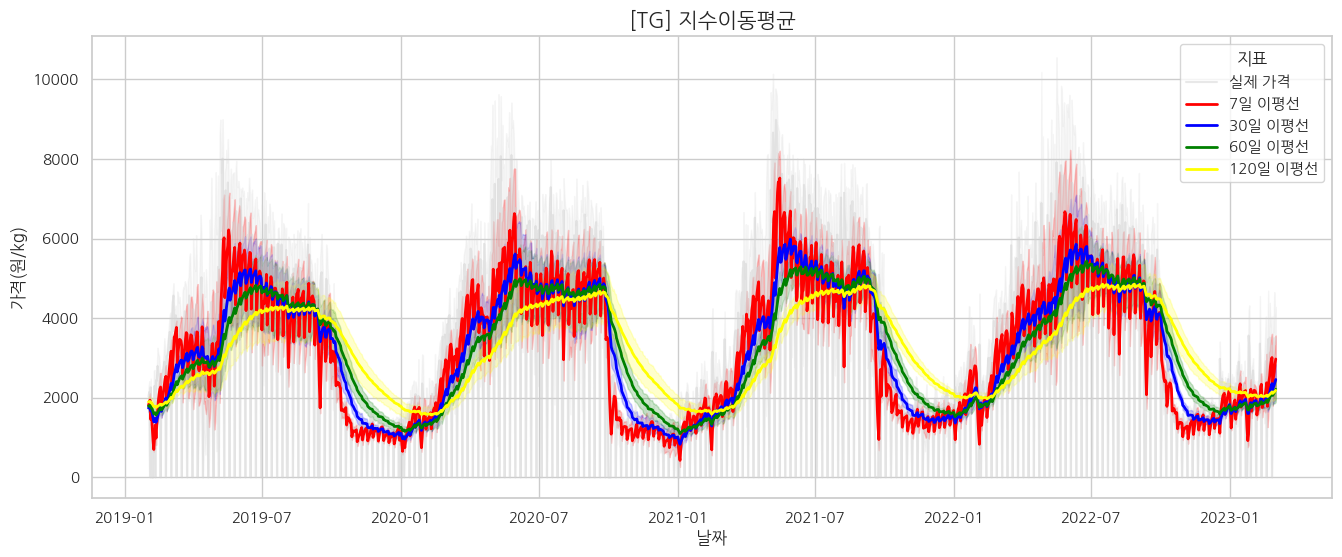

In [16]:
sns.set(font="NanumGothic", rc={"axes.unicode_minus": False}, style='whitegrid')

# 데이터 설정
target_item = 'TG'
plot_df = train_df[(train_df['item'] == target_item) & (train_df['timestamp'] >= '2019-02-01')].copy()

plt.figure(figsize=(16, 6))

# 실제 가격
sns.lineplot(data=plot_df, x='timestamp', y='price', color='lightgrey', alpha=0.5, label='실제 가격')


sns.lineplot(data=plot_df, x='timestamp', y='price_7d_avg', color='red', linewidth=2, label='7일 이평선')
sns.lineplot(data=plot_df, x='timestamp', y='price_30d_avg', color='blue', linewidth=2, label='30일 이평선')
sns.lineplot(data=plot_df, x='timestamp', y='price_60d_avg', color='green', linewidth=2, label='60일 이평선')
sns.lineplot(data=plot_df, x='timestamp', y='price_120d_avg', color='yellow', linewidth=2, label='120일 이평선')

plt.title(f'[{target_item}] 지수이동평균', fontsize=15)
plt.ylabel('가격(원/kg)')
plt.xlabel('날짜')
plt.legend(title='지표')
plt.show()

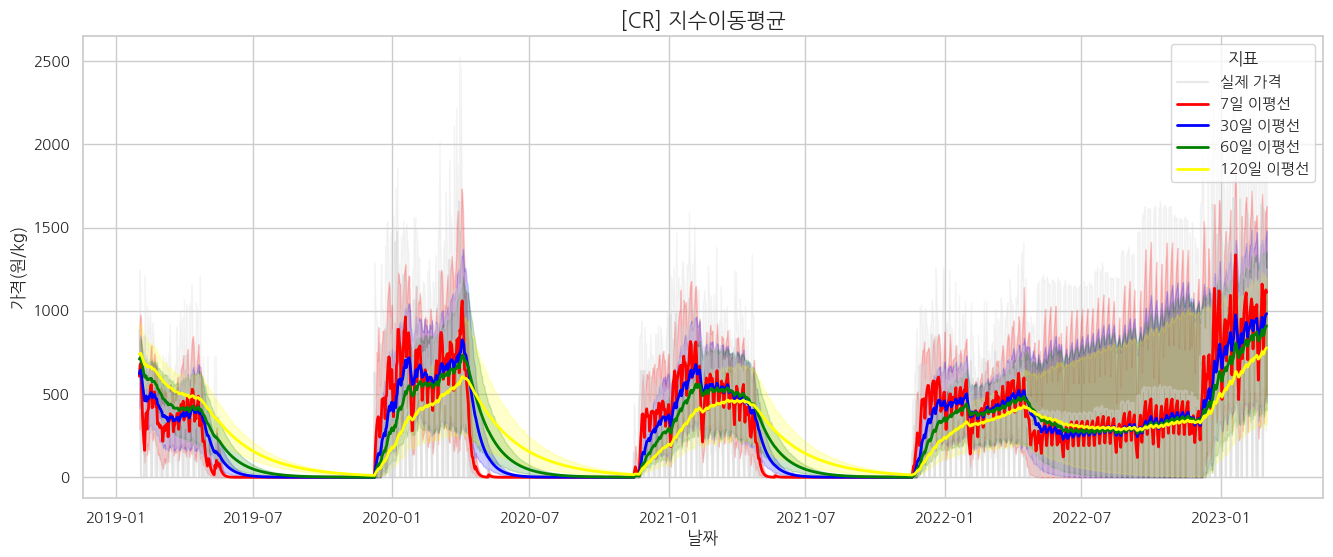

In [17]:
sns.set(font="NanumGothic", rc={"axes.unicode_minus": False}, style='whitegrid')

# 데이터 설정
target_item = 'CR'
plot_df = train_df[(train_df['item'] == target_item) & (train_df['timestamp'] >= '2019-02-01')].copy()

plt.figure(figsize=(16, 6))

# 실제 가격
sns.lineplot(data=plot_df, x='timestamp', y='price', color='lightgrey', alpha=0.5, label='실제 가격')


sns.lineplot(data=plot_df, x='timestamp', y='price_7d_avg', color='red', linewidth=2, label='7일 이평선')
sns.lineplot(data=plot_df, x='timestamp', y='price_30d_avg', color='blue', linewidth=2, label='30일 이평선')
sns.lineplot(data=plot_df, x='timestamp', y='price_60d_avg', color='green', linewidth=2, label='60일 이평선')
sns.lineplot(data=plot_df, x='timestamp', y='price_120d_avg', color='yellow', linewidth=2, label='120일 이평선')

plt.title(f'[{target_item}] 지수이동평균', fontsize=15)
plt.ylabel('가격(원/kg)')
plt.xlabel('날짜')
plt.legend(title='지표')
plt.show()

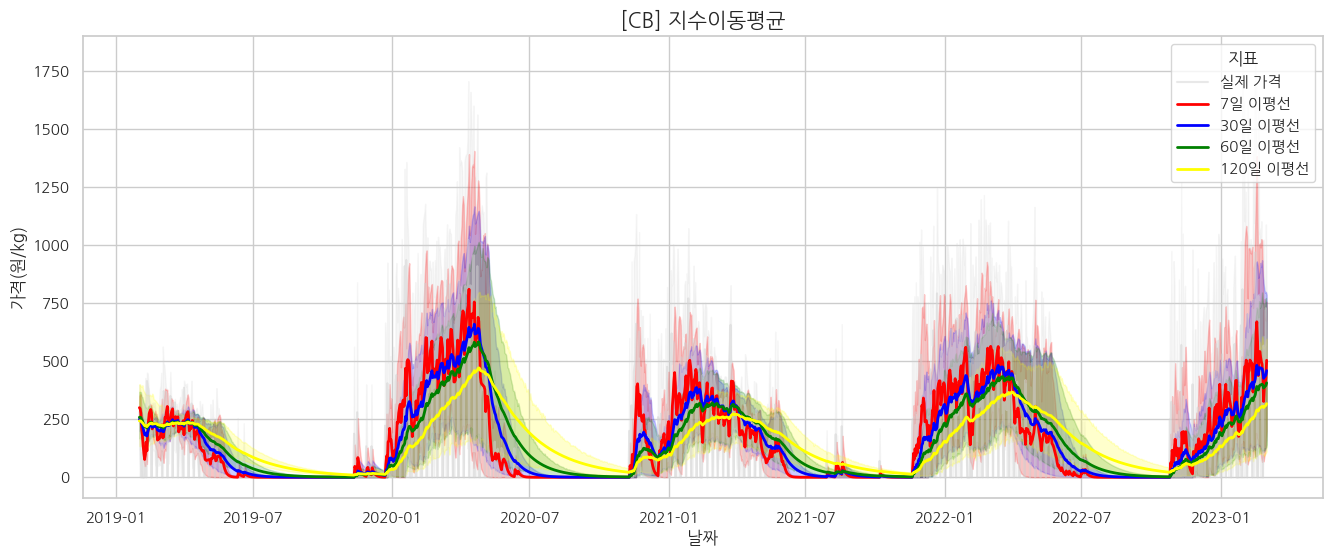

In [18]:
sns.set(font="NanumGothic", rc={"axes.unicode_minus": False}, style='whitegrid')

# 데이터 설정
target_item = 'CB'
plot_df = train_df[(train_df['item'] == target_item) & (train_df['timestamp'] >= '2019-02-01')].copy()

plt.figure(figsize=(16, 6))

# 실제 가격
sns.lineplot(data=plot_df, x='timestamp', y='price', color='lightgrey', alpha=0.5, label='실제 가격')


sns.lineplot(data=plot_df, x='timestamp', y='price_7d_avg', color='red', linewidth=2, label='7일 이평선')
sns.lineplot(data=plot_df, x='timestamp', y='price_30d_avg', color='blue', linewidth=2, label='30일 이평선')
sns.lineplot(data=plot_df, x='timestamp', y='price_60d_avg', color='green', linewidth=2, label='60일 이평선')
sns.lineplot(data=plot_df, x='timestamp', y='price_120d_avg', color='yellow', linewidth=2, label='120일 이평선')

plt.title(f'[{target_item}] 지수이동평균', fontsize=15)
plt.ylabel('가격(원/kg)')
plt.xlabel('날짜')
plt.legend(title='지표')
plt.show()

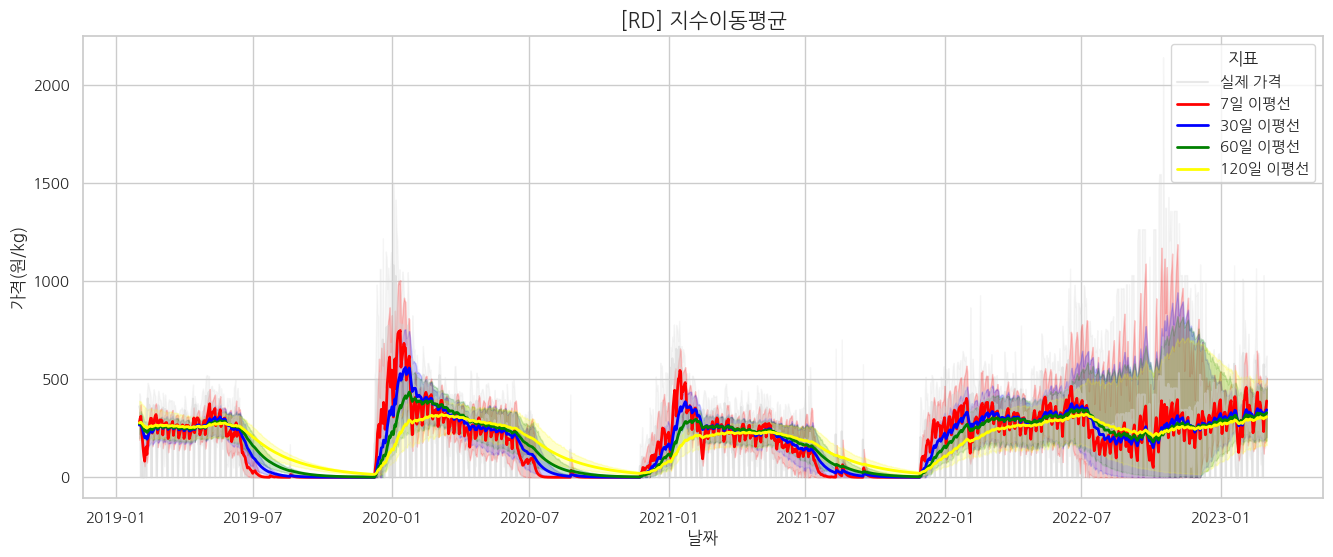

In [19]:
sns.set(font="NanumGothic", rc={"axes.unicode_minus": False}, style='whitegrid')

# 데이터 설정
target_item = 'RD'
plot_df = train_df[(train_df['item'] == target_item) & (train_df['timestamp'] >= '2019-02-01')].copy()

plt.figure(figsize=(16, 6))

# 실제 가격
sns.lineplot(data=plot_df, x='timestamp', y='price', color='lightgrey', alpha=0.5, label='실제 가격')


sns.lineplot(data=plot_df, x='timestamp', y='price_7d_avg', color='red', linewidth=2, label='7일 이평선')
sns.lineplot(data=plot_df, x='timestamp', y='price_30d_avg', color='blue', linewidth=2, label='30일 이평선')
sns.lineplot(data=plot_df, x='timestamp', y='price_60d_avg', color='green', linewidth=2, label='60일 이평선')
sns.lineplot(data=plot_df, x='timestamp', y='price_120d_avg', color='yellow', linewidth=2, label='120일 이평선')

plt.title(f'[{target_item}] 지수이동평균', fontsize=15)
plt.ylabel('가격(원/kg)')
plt.xlabel('날짜')
plt.legend(title='지표')
plt.show()

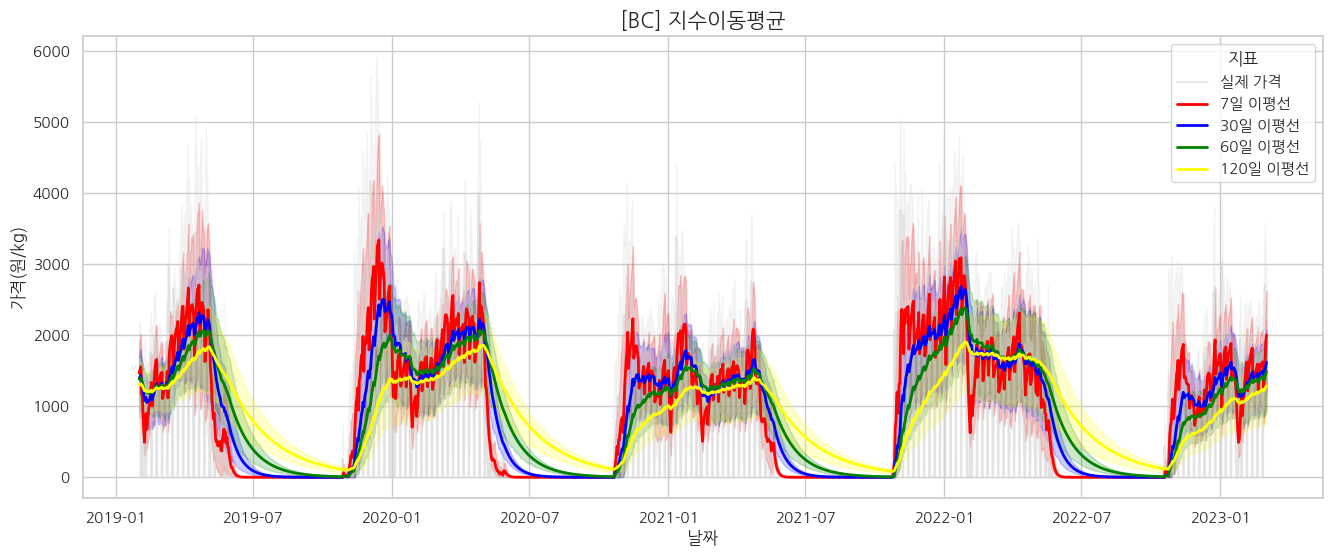

In [20]:
sns.set(font="NanumGothic", rc={"axes.unicode_minus": False}, style='whitegrid')

# 데이터 설정
target_item = 'BC'
plot_df = train_df[(train_df['item'] == target_item) & (train_df['timestamp'] >= '2019-02-01')].copy()

plt.figure(figsize=(16, 6))

# 실제 가격
sns.lineplot(data=plot_df, x='timestamp', y='price', color='lightgrey', alpha=0.5, label='실제 가격')


sns.lineplot(data=plot_df, x='timestamp', y='price_7d_avg', color='red', linewidth=2, label='7일 이평선')
sns.lineplot(data=plot_df, x='timestamp', y='price_30d_avg', color='blue', linewidth=2, label='30일 이평선')
sns.lineplot(data=plot_df, x='timestamp', y='price_60d_avg', color='green', linewidth=2, label='60일 이평선')
sns.lineplot(data=plot_df, x='timestamp', y='price_120d_avg', color='yellow', linewidth=2, label='120일 이평선')

plt.title(f'[{target_item}] 지수이동평균', fontsize=15)
plt.ylabel('가격(원/kg)')
plt.xlabel('날짜')
plt.legend(title='지표')
plt.show()

* TG와 나머지 4종류의 데이터 특성이 다름
* RD와 CR의 데이터 특성이 비슷함
* CB와 BC의 데이터 특성이 비슷함

* 이는 어떤 종류의 농산물인지, 재배되는 환경과 판매시기가 다르기 때문에   
  3종류의 모델을 따로 계산해서 병합하는 모델링이 필요해보임